In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [2]:
df1 = pd.read_csv('../precio_consumidor_2008-2026.csv')

In [3]:
df2 = pd.read_csv('../IPC_Mensual.csv', sep=";")

In [4]:
display(df1.head())
print("Dimensiones:", df1.shape)
df1.info()

,Anio,Mes,Semana,Fecha inicio,Fecha termino,ID region,Region,Sector,Tipo de punto monitoreo,Grupo,Producto,Unidad,Precio minimo,Precio maximo,Precio promedio
0,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Limón|Sin especificar|1a plateado,$/kilo,NaN,NaN,"1000,000000"
1,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Manzana|Fuji|Primera,$/kilo,NaN,NaN,"400,000000"
2,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Manzana|Granny Smith|Primera,$/kilo,NaN,NaN,"350,000000"
3,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Naranja|Navel Late|Primera,$/kilo,NaN,NaN,"400,000000"
4,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Palta|Hass|Primera,$/kilo,NaN,NaN,"1200,000000"


Dimensiones: (3962152, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962152 entries, 0 to 3962151
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Anio                     int64  
 1   Mes                      int64  
 2   Semana                   int64  
 3   Fecha inicio             object 
 4   Fecha termino            object 
 5   ID region                int64  
 6   Region                   object 
 7   Sector                   object 
 8   Tipo de punto monitoreo  object 
 9   Grupo                    object 
 10  Producto                 object 
 11  Unidad                   object 
 12  Precio minimo            float64
 13  Precio maximo            float64
 14  Precio promedio          object 
dtypes: float64(2), int64(4), object(9)
memory usage: 453.4+ MB


In [5]:
display(df2.head())
print("Dimensiones:", df2.shape)
df2.info()

,Mes,Anio,ValorIPC
0,ene,2008,0.0
1,feb,2008,0.4
2,mar,2008,0.8
3,abr,2008,0.4
4,may,2008,1.2


Dimensiones: (216, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Mes       216 non-null    object 
 1   Anio      216 non-null    int64  
 2   ValorIPC  216 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 5.2+ KB


¿Cuáles son los productos cuyos precios reaccionan más rápido a los cambios en el IPC mensual? -> Entender cómo el cambio en el costo de la vida general afecta a productos específicos.

¿Existe una brecha de precios significativa entre las ferias libres y los supermercados para la misma canasta de productos a lo largo de los años? -> Segmentación de mercado.

¿Qué eventos históricos provocaron desviaciones atípicas en los precios sin ser percibidas inmediatamente por el IPC general? -> Identificar comportamientos fuera de lo común justificados por distintos eventos históricos (crisis económicas, eventos climáticos o sociales, etc.).

In [6]:
df1.isna().sum()

Anio                           0
Mes                            0
Semana                         0
Fecha inicio                   0
Fecha termino                  0
ID region                      0
Region                         0
Sector                         0
Tipo de punto monitoreo        0
Grupo                          0
Producto                       0
Unidad                         0
Precio minimo              71989
Precio maximo              71989
Precio promedio                0
dtype: int64

Los datos faltantes corresponden a precio mínimo y máximo entre los años 2008 y 2012, pues allí solo se estipulaba el precio promedio. Dejaré esos datos puesto que, a pesar de no tener esos valores, está el promedio y sobre ese valor se pueden hacer análisis igualmente.

In [7]:
df2.isna().sum()

Mes         0
Anio        0
ValorIPC    0
dtype: int64

In [8]:
print("Total de filas duplicadas:", df1.duplicated().sum())

Total de filas duplicadas: 0


In [9]:
df1.describe()

,Anio,Mes,Semana,ID region,Precio minimo,Precio maximo
count,3.962152e+06,3.962152e+06,3.962152e+06,3.962152e+06,3.890163e+06,3.890163e+06
mean,2.019708e+03,6.418379e+00,2.619325e+01,9.213173e+00,3.080920e+03,3.695617e+03
std,3.688839e+00,3.499931e+00,1.526428e+01,3.516901e+00,3.339025e+03,3.919909e+03
min,2.008000e+03,1.000000e+00,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
25%,2.017000e+03,3.000000e+00,1.300000e+01,7.000000e+00,8.190000e+02,1.000000e+03
50%,2.020000e+03,6.000000e+00,2.600000e+01,9.000000e+00,1.690000e+03,2.000000e+03
75%,2.023000e+03,1.000000e+01,4.000000e+01,1.300000e+01,4.590000e+03,5.499000e+03
max,2.026000e+03,1.200000e+01,5.300000e+01,1.600000e+01,5.000000e+04,1.415560e+05


In [10]:
df2.describe()

,Anio,ValorIPC
count,216.000000,216.000000
mean,2016.500000,0.324074
std,5.200179,0.425331
min,2008.000000,-1.200000
25%,2012.000000,0.100000
50%,2016.500000,0.300000
75%,2021.000000,0.500000
max,2025.000000,1.900000


In [11]:
df1['Precio promedio'] = pd.to_numeric(df1['Precio promedio'].str.replace(',', '.'), errors='coerce')
print(df1['Precio promedio'].dtype)

float64


In [12]:

df1['Fecha_Mes'] = pd.to_datetime(df1['Anio'].astype(str) + '-' + df1['Mes'].astype(str) + '-01')

In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962152 entries, 0 to 3962151
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   Anio                     int64         
 1   Mes                      int64         
 2   Semana                   int64         
 3   Fecha inicio             object        
 4   Fecha termino            object        
 5   ID region                int64         
 6   Region                   object        
 7   Sector                   object        
 8   Tipo de punto monitoreo  object        
 9   Grupo                    object        
 10  Producto                 object        
 11  Unidad                   object        
 12  Precio minimo            float64       
 13  Precio maximo            float64       
 14  Precio promedio          float64       
 15  Fecha_Mes                datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(4), object(8)
memory usage: 483.

Se generó esta nueva columna para hacer más simple la unión entre el valor del IPC (que es mensual) con la tabla de precio_consumidor.

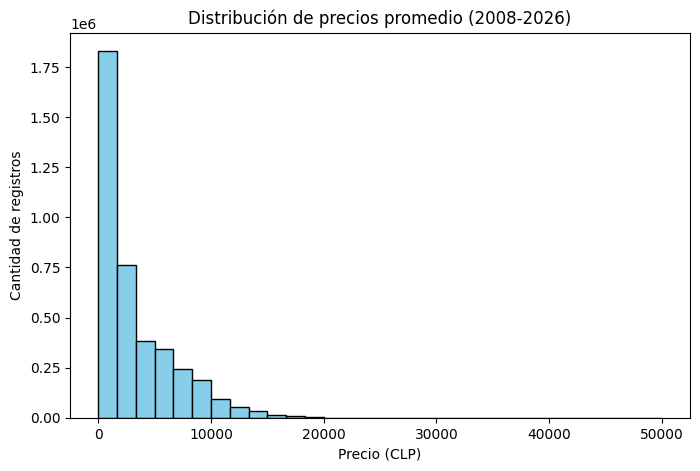

In [14]:
plt.figure(figsize=(8, 5))
df1['Precio promedio'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de precios promedio (2008-2026)')
plt.xlabel('Precio (CLP)')
plt.ylabel('Cantidad de registros')
plt.show()

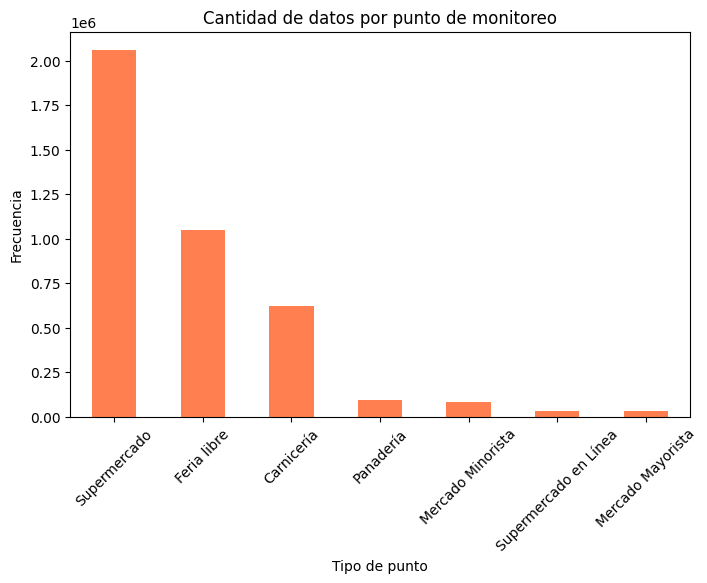

In [15]:
plt.figure(figsize=(8, 5))
df1['Tipo de punto monitoreo'].value_counts().plot(kind='bar', color='coral')
plt.title('Cantidad de datos por punto de monitoreo')
plt.xlabel('Tipo de punto')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [16]:
sesgo = stats.skew(df1['Precio promedio'].dropna())
print(f"Sesgo (Skewness): {sesgo}")

Sesgo (Skewness): 2.3826574213782514


In [17]:
curtosis = stats.kurtosis(df1['Precio promedio'].dropna())
print(f"Curtosis: {curtosis}")

Curtosis: 11.897697759107356


In [18]:
df1['Precio_promedioLog'] = np.log1p(df1['Precio promedio'])


In [19]:
sesgo = stats.skew(df1['Precio_promedioLog'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(df1['Precio_promedioLog'].dropna())
print(f"Curtosis: {curtosis}")

Sesgo (Skewness): -0.13998858779246584
Curtosis: -0.5312881009001389


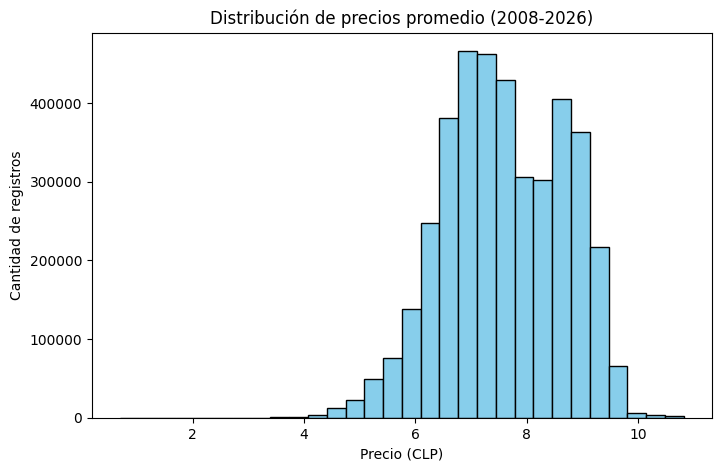

In [20]:
plt.figure(figsize=(8, 5))
df1['Precio_promedioLog'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de precios promedio (2008-2026)')
plt.xlabel('Precio (CLP)')
plt.ylabel('Cantidad de registros')
plt.show()

In [21]:
minimo = df1['Precio promedio'].min()
maximo = df1['Precio promedio'].max()
df1['Precio promedio MINMAX'] = (df1['Precio promedio'] - minimo) / (maximo
- minimo)

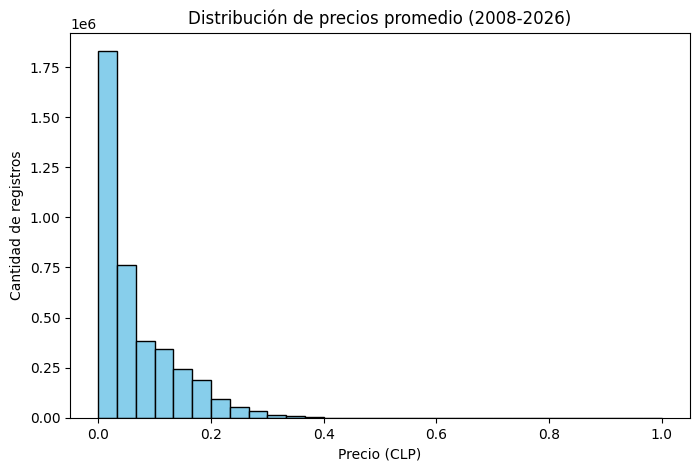

In [22]:
plt.figure(figsize=(8, 5))
df1['Precio promedio MINMAX'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de precios promedio (2008-2026)')
plt.xlabel('Precio (CLP)')
plt.ylabel('Cantidad de registros')
plt.show()

In [23]:
month_map = {
    'ene': 1, 'feb': 2, 'mar': 3, 'abr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'ago': 8, 'sept': 9, 'oct': 10, 'nov': 11, 'dic': 12
}
df2['Mes_Num'] = df2['Mes'].map(month_map)

df_final = pd.merge(
    df1, 
    df2[['Anio', 'Mes_Num', 'ValorIPC']], 
    left_on=['Anio', 'Mes'], 
    right_on=['Anio', 'Mes_Num'], 
    how='left'
)

df_final = df_final.drop(columns=['Mes_Num'])
df_final.to_csv('precios_consumidor_total_con_IPC.csv', index=False, sep=';')

In [24]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962152 entries, 0 to 3962151
Data columns (total 19 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   Anio                     int64         
 1   Mes                      int64         
 2   Semana                   int64         
 3   Fecha inicio             object        
 4   Fecha termino            object        
 5   ID region                int64         
 6   Region                   object        
 7   Sector                   object        
 8   Tipo de punto monitoreo  object        
 9   Grupo                    object        
 10  Producto                 object        
 11  Unidad                   object        
 12  Precio minimo            float64       
 13  Precio maximo            float64       
 14  Precio promedio          float64       
 15  Fecha_Mes                datetime64[ns]
 16  Precio_promedioLog       float64       
 17  Precio promedio MINMAX   fl

In [25]:
PALETTE   = "viridis"
ACCENT    = "#E84855"          # rojo destacado
NEUTRAL   = "#2D4059"          # azul oscuro
BG        = "#F8F9FA"
GRID_CLR  = "#DEE2E6"

In [26]:
ipc_mes = (df_final[["Anio","Mes","ValorIPC"]].drop_duplicates()
           .sort_values(["Anio","Mes"])
           .assign(fecha=lambda x: pd.to_datetime(
               x["Anio"].astype(str)+"-"+x["Mes"].astype(str)+"-01"))
           .set_index("fecha")["ValorIPC"])

precio_prod = (df_final.groupby(["Fecha_Mes","Producto"])["Precio promedio"]
               .mean().unstack("Producto").sort_index())
precio_prod = precio_prod.loc[:, precio_prod.notna().sum() >= 24]
cambio_precio = precio_prod.pct_change() * 100
ipc_alin = ipc_mes.reindex(cambio_precio.index)

correlaciones = {}
for prod in cambio_precio.columns:
    serie = cambio_precio[prod].dropna()
    ipc_s = ipc_alin.reindex(serie.index).dropna()
    comun = serie.index.intersection(ipc_s.index)
    if len(comun) < 20:
        continue
    lags = {}
    for lag in [0, 1, 2]:
        x = ipc_s.loc[comun]
        y = serie.loc[comun]
        if lag > 0:
            x = x.shift(lag).dropna()
            y = y.reindex(x.index).dropna()
            x = x.reindex(y.index)
        if len(x) < 15:
            continue
        r, p = stats.pearsonr(x, y)
        lags[f"lag{lag}"] = r
        if lag == 0:
            lags["p"] = p
    if "p" in lags:
        correlaciones[prod] = lags

corr_df = pd.DataFrame(correlaciones).T.dropna(subset=["p"])
corr_df = corr_df[corr_df["p"] < 0.05].sort_values("lag0", ascending=False)
top_pos = corr_df.head(12)
top_neg = corr_df.tail(8)

C:\Users\amand\AppData\Local\Temp\ipykernel_25844\974183151.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cambio_precio = precio_prod.pct_change() * 100


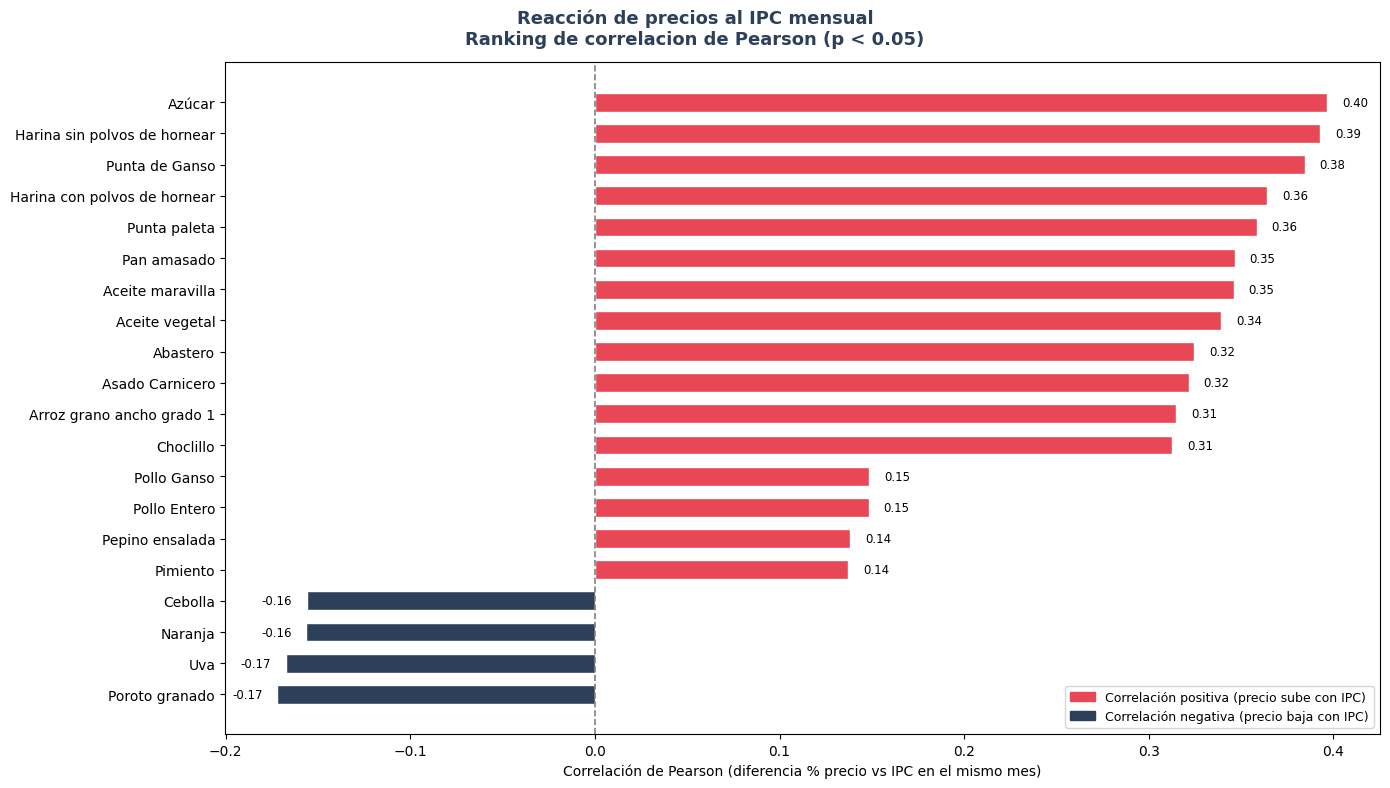

In [27]:
combined = pd.concat([top_pos, top_neg]).sort_values("lag0")
nombres  = [p.split("|")[0].strip()[:38] for p in combined.index]
colores  = [ACCENT if r >= 0 else NEUTRAL for r in combined["lag0"]]

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Reacción de precios al IPC mensual\nRanking de correlacion de Pearson (p < 0.05)",
             fontsize=13, fontweight="bold", color=NEUTRAL)
bars = ax.barh(nombres, combined["lag0"], color=colores, height=0.6, edgecolor="white")
ax.axvline(0, color="gray", lw=1.2, ls="--")
ax.set_xlabel("Correlación de Pearson (diferencia % precio vs IPC en el mismo mes)")
for bar, r in zip(bars, combined["lag0"]):
    ax.text(r + (0.008 if r >= 0 else -0.008), bar.get_y() + bar.get_height()/2,
            f"{r:.2f}", va="center", ha="left" if r >= 0 else "right", fontsize=8.5)
patch_pos = mpatches.Patch(color=ACCENT, label="Correlación positiva (precio sube con IPC)")
patch_neg = mpatches.Patch(color=NEUTRAL, label="Correlación negativa (precio baja con IPC)")
ax.legend(handles=[patch_pos, patch_neg], fontsize=9, loc="lower right")
fig.tight_layout()

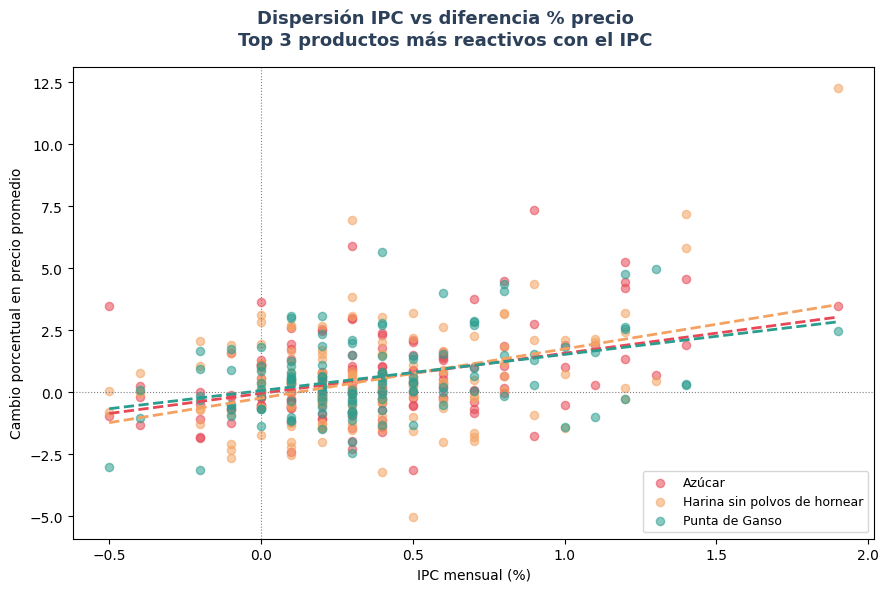

In [28]:
top3 = top_pos.head(3).index.tolist()
colors3 = [ACCENT, "#F4A261", "#2A9D8F"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("Dispersión IPC vs diferencia % precio\nTop 3 productos más reactivos con el IPC",
             fontsize=13, fontweight="bold", color=NEUTRAL)
for prod, col in zip(top3, colors3):
    s = cambio_precio[prod].dropna()
    ipc_s = ipc_alin.reindex(s.index).dropna()
    comun = s.index.intersection(ipc_s.index)
    ax.scatter(ipc_s.loc[comun], s.loc[comun], alpha=0.55, s=35,
               color=col, label=prod.split("|")[0].strip()[:30])
    m, b, *_ = stats.linregress(ipc_s.loc[comun], s.loc[comun])
    xr = np.linspace(ipc_s.loc[comun].min(), ipc_s.loc[comun].max(), 80)
    ax.plot(xr, m*xr+b, color=col, lw=2, ls="--")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("IPC mensual (%)")
ax.set_ylabel("Cambio porcentual en precio promedio")
ax.legend(fontsize=9)
fig.tight_layout()

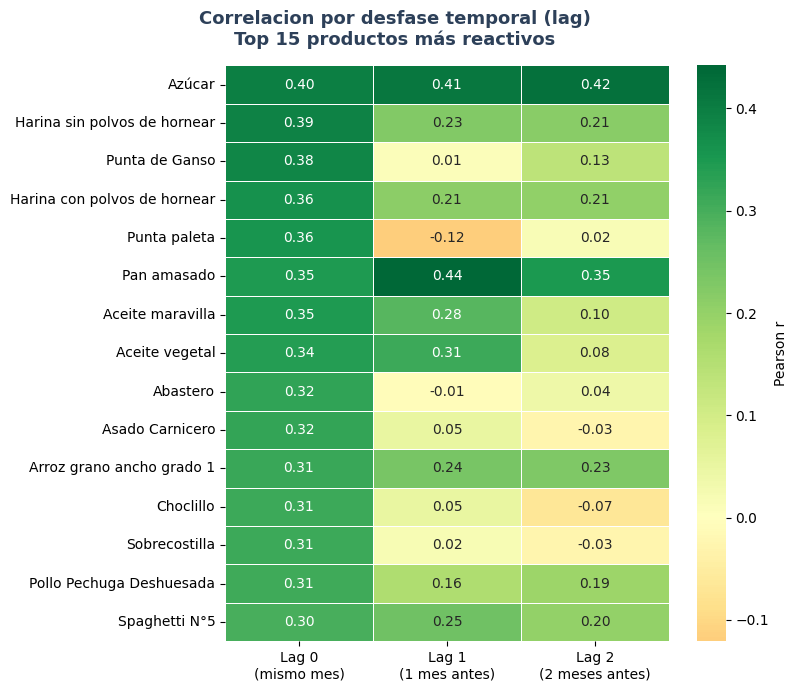

In [29]:
top15 = corr_df.head(15)
heat_data = top15[["lag0","lag1","lag2"]].copy()
heat_data.index = [p.split("|")[0].strip()[:30] for p in heat_data.index]
heat_data.columns = ["Lag 0\n(mismo mes)", "Lag 1\n(1 mes antes)", "Lag 2\n(2 meses antes)"]

fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Correlacion por desfase temporal (lag)\nTop 15 productos más reactivos",
             fontsize=13, fontweight="bold", color=NEUTRAL)
sns.heatmap(heat_data.astype(float), ax=ax, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.4,
            cbar_kws={"label": "Pearson r"})
ax.set_ylabel("")
fig.tight_layout()

In [30]:
FL_COLOR = "#2A9D8F"   # verde azulado → feria libre
SM_COLOR = "#E84855"   # rojo          → supermercado
BG       = "#F8F9FA"
GRID_CLR = "#DEE2E6"
NEUTRAL  = "#2D4059"

In [31]:
df_final["Fecha_Mes"] = pd.to_datetime(df_final["Fecha_Mes"])
df_final["Precio promedio"] = pd.to_numeric(df_final["Precio promedio"], errors="coerce")
df_final.dropna(subset=["Precio promedio"], inplace=True)

In [32]:
canales = df_final[df_final["Tipo de punto monitoreo"].isin(["Feria libre", "Supermercado"])].copy()

conteo = (canales.groupby(["Producto", "Tipo de punto monitoreo"])["Fecha_Mes"]
          .nunique().unstack("Tipo de punto monitoreo").dropna())
conteo = conteo[(conteo["Feria libre"] >= 36) & (conteo["Supermercado"] >= 36)]
conteo["total"] = conteo["Feria libre"] + conteo["Supermercado"]

top12_prods = conteo.sort_values("total", ascending=False).head(12).index.tolist()
canasta = canales[canales["Producto"].isin(top12_prods)].copy()
canasta["nombre"] = canasta["Producto"].str.split("|").str[0].str.strip()
orden_mediana = (canasta[canasta["Tipo de punto monitoreo"] == "Feria libre"]
                 .groupby("nombre")["Precio promedio"].median()
                 .sort_values())
orden = orden_mediana.index.tolist()

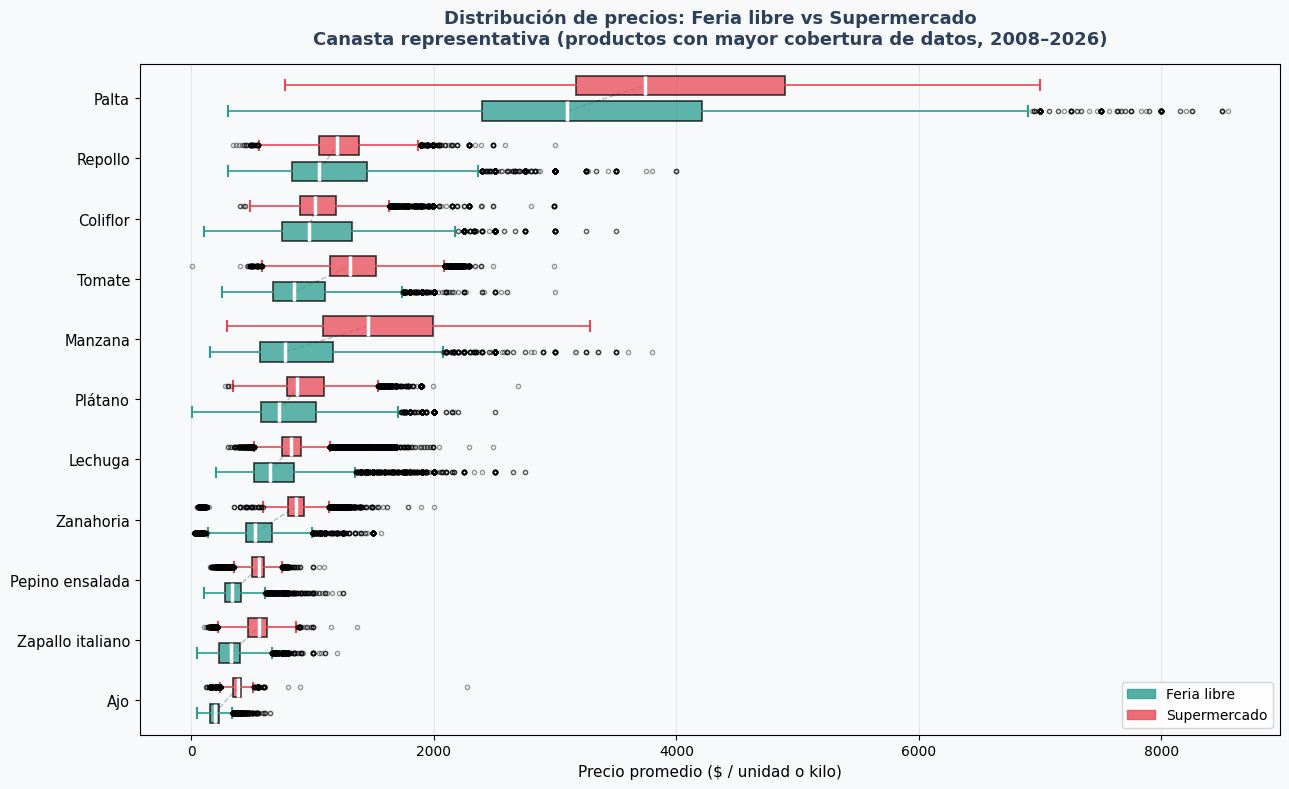

In [37]:
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
positions_fl = []
positions_sm = []
gap = 1.4   
offset = 0.3

for i, prod in enumerate(orden):
    y_center = i * gap
    positions_fl.append(y_center - offset)
    positions_sm.append(y_center + offset)

fl_data = [canasta[(canasta["nombre"] == p) & (canasta["Tipo de punto monitoreo"] == "Feria libre")]["Precio promedio"].values for p in orden]
sm_data = [canasta[(canasta["nombre"] == p) & (canasta["Tipo de punto monitoreo"] == "Supermercado")]["Precio promedio"].values for p in orden]

bp_fl = ax.boxplot(fl_data, positions=positions_fl, vert=False, widths=0.45,
                   patch_artist=True, notch=False,
                   boxprops=dict(facecolor=FL_COLOR, alpha=0.75, linewidth=1.2),
                   medianprops=dict(color="white", linewidth=2.5),
                   whiskerprops=dict(color=FL_COLOR, linewidth=1.2),
                   capprops=dict(color=FL_COLOR, linewidth=1.5),
                   flierprops=dict(marker="o", color=FL_COLOR, markersize=3, alpha=0.4))

bp_sm = ax.boxplot(sm_data, positions=positions_sm, vert=False, widths=0.45,
                   patch_artist=True, notch=False,
                   boxprops=dict(facecolor=SM_COLOR, alpha=0.75, linewidth=1.2),
                   medianprops=dict(color="white", linewidth=2.5),
                   whiskerprops=dict(color=SM_COLOR, linewidth=1.2),
                   capprops=dict(color=SM_COLOR, linewidth=1.5),
                   flierprops=dict(marker="o", color=SM_COLOR, markersize=3, alpha=0.4))

for pfl, psm, dfl, dsm in zip(positions_fl, positions_sm, fl_data, sm_data):
    med_fl = np.median(dfl)
    med_sm = np.median(dsm)
    ax.plot([med_fl, med_sm], [pfl, psm], color="gray", lw=1, ls="--", alpha=0.5, zorder=0)

yticks = [(pfl + psm) / 2 for pfl, psm in zip(positions_fl, positions_sm)]
ax.set_yticks(yticks)
ax.set_yticklabels(orden, fontsize=10.5)

ax.set_xlabel("Precio promedio ($ / unidad o kilo)", fontsize=11)
ax.set_title(
    "Distribución de precios: Feria libre vs Supermercado\nCanasta representativa (productos con mayor cobertura de datos, 2008–2026)",
    fontsize=13, fontweight="bold", color=NEUTRAL, pad=14)

patch_fl = mpatches.Patch(color=FL_COLOR, alpha=0.8, label="Feria libre")
patch_sm = mpatches.Patch(color=SM_COLOR, alpha=0.8, label="Supermercado")
ax.legend(handles=[patch_fl, patch_sm], fontsize=10, loc="lower right")

ax.grid(axis="x", color=GRID_CLR, linewidth=0.6)
ax.grid(axis="y", visible=False)
plt.tight_layout()

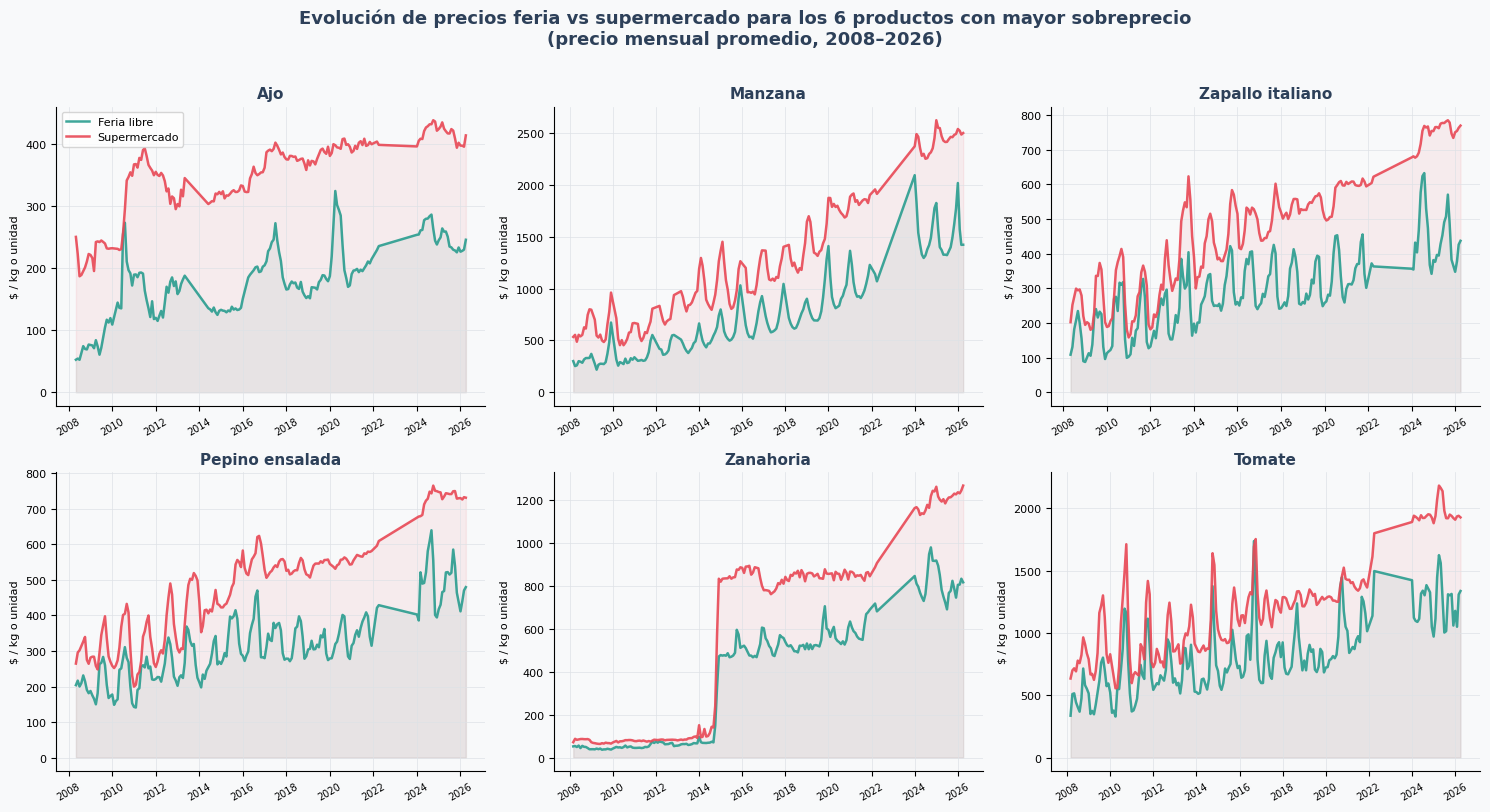

In [40]:
resumen = []
for prod in top12_prods:
    nombre = prod.split("|")[0].strip()
    fl_vals = canasta[(canasta["Producto"] == prod) & (canasta["Tipo de punto monitoreo"] == "Feria libre")]["Precio promedio"]
    sm_vals = canasta[(canasta["Producto"] == prod) & (canasta["Tipo de punto monitoreo"] == "Supermercado")]["Precio promedio"]
    if len(fl_vals) < 5 or len(sm_vals) < 5:
        continue
    med_fl = fl_vals.median()
    med_sm = sm_vals.median()
    ahorro_abs = med_sm - med_fl
    ahorro_pct = (ahorro_abs / med_fl) * 100
    stat, pval = stats.mannwhitneyu(fl_vals, sm_vals, alternative="two-sided")
    resumen.append({
        "nombre": nombre, "med_fl": med_fl, "med_sm": med_sm,
        "ahorro_abs": ahorro_abs, "ahorro_pct": ahorro_pct, "pval": pval
    })

res_df = pd.DataFrame(resumen).sort_values("ahorro_pct", ascending=True)
top6 = res_df.sort_values("ahorro_pct", ascending=False).head(6)["nombre"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for ax, nombre in zip(axes, top6):
    prod_full = [p for p in top12_prods if p.split("|")[0].strip() == nombre][0]
    for canal, col, lbl in [("Feria libre", FL_COLOR, "Feria libre"),
                             ("Supermercado", SM_COLOR, "Supermercado")]:
        sub = (canasta[(canasta["Producto"] == prod_full) &
                       (canasta["Tipo de punto monitoreo"] == canal)]
               .groupby("Fecha_Mes")["Precio promedio"].mean().reset_index()
               .sort_values("Fecha_Mes"))
        ax.plot(sub["Fecha_Mes"], sub["Precio promedio"], color=col,
                lw=1.8, label=lbl, alpha=0.9)
        ax.fill_between(sub["Fecha_Mes"], sub["Precio promedio"], alpha=0.08, color=col)

    ax.set_title(nombre, fontsize=11, fontweight="bold", color=NEUTRAL)
    ax.set_xlabel("")
    ax.set_ylabel("$ / kg o unidad", fontsize=8)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_facecolor(BG)
    ax.grid(color=GRID_CLR, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle(
    "Evolución de precios feria vs supermercado para los 6 productos con mayor sobreprecio\n(precio mensual promedio, 2008–2026)",
    fontsize=13, fontweight="bold", color=NEUTRAL, y=1.01)
plt.tight_layout()